In [1]:
import torch
import torch.nn as nn
import geopandas as gpd
import shapely
import matplotlib.pyplot as plt
import numpy as np

# Get Geometry

In [2]:
# Belgium Border
border = gpd.read_file("border_bg.geojson")

# Interesting part of border
bbox = shapely.geometry.box(4.9, 51.42, 4.96, 51.46)
borderparts = gpd.GeoSeries(border.geometry[0].geoms, crs=4326)
barrleNassau = borderparts[borderparts.within(bbox)]

# Better CRS
barrleNassau = barrleNassau.to_crs(25832)

# Encode Holes correctly
polygons = []
for borderpart in barrleNassau.geometry:
    found = False
    for i, p in enumerate(polygons):
        if shapely.within(borderpart, p):  # Is hole?
            holes = list(p.interiors) + [borderpart.exterior]
            polygons[i] = shapely.geometry.Polygon(p.exterior, holes)
            found = True
            break
    if not found:
        polygons.append(borderpart)
barrleNassau = gpd.GeoSeries(polygons)

<Axes: >

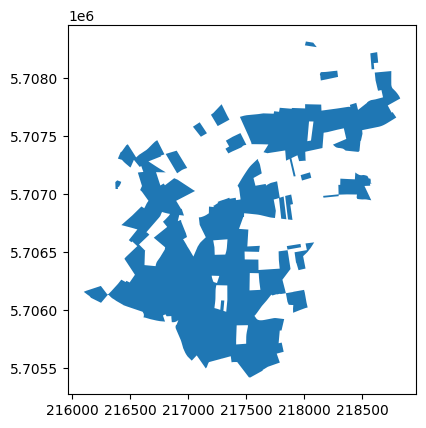

In [3]:
# Check
f, ax = plt.subplots()
barrleNassau.plot(figsize=(15, 15), ax=ax)

# Triangulate

In [ ]:
triangles = shapely.constrained_delaunay_triangles(barrleNassau.union_all())
triangles = shapely.ops.orient(triangles) # Order triangle nodes counter-clockwise
triangles = list(triangles.geoms)

<Axes: >

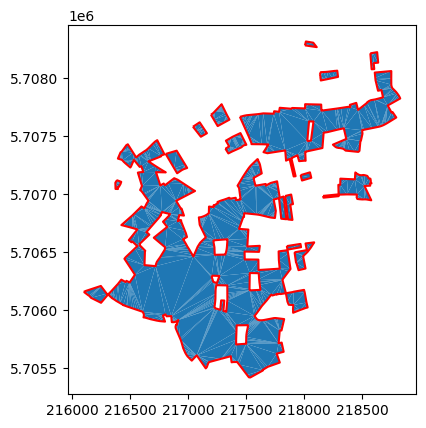

In [11]:
# Check
f, ax = plt.subplots()
gpd.GeoSeries(triangles).plot(ax=ax)
barrleNassau.boundary.plot(ax=ax, color="red")

# Build Network

### Get weights

Function to determine if a point c is left of the line between a and b:

    (b.x - a.x) * (c.y - a.y) - (b.y - a.y) * (c.x - a.x) > 0

Rearange ->

    -x * (b.y - a.y) + y * (b.x - a.x) - a.y * (b.x - a.x)  + a.x * (b.y - ay.) > 0

              wx                wy                        bias                   


-> 

    wx = -(b.y - a.y)

    wy = (b.x - a.x)

    b = - a.y * (b.x - a.x) + a.x * (b.y - a.y)


In [ ]:
class WithinTriangleNet(nn.Module):
    def __init__(self):
        super(WithinTriangleNet, self).__init__()
        self.layer1 = nn.Linear(2, 3 * len(triangles)) # Check if point is on the correct side fore of each edge of each triangle
        self.relu = nn.ReLU() # Points inside one triangle will get zeroed, others will be negative
        self.layer2 = nn.Linear(3 * len(triangles), len(triangles)) # Add all results for the edges of one triangle
        self.relu2 = nn.ReLU() # Zero Result if any are below zero. If all a zero we add a small value eps.
        self.layer3 = nn.Linear(len(triangles), 1) # Output Layer
        
    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.relu2(x)
        x = self.layer3(x)
        return x

model = WithinTriangleNet()
eps = 0.001

# Get weights that represent each line/edge check
weights1 = []
biases1 = []
for triangle in triangles:
    for i in range(3):
        a = triangle.exterior.coords[i]
        b = triangle.exterior.coords[i+1]
        
        w = [ -(b[1] - a[1]) , b[0] - a[0] ]
        bias = -a[1] * (b[0] - a[0]) + a[0] * (b[1] - a[1])

        weights1.append( [-w[0], -w[1]] ) # Flip sign so that values on the correct side of the line will be negative and therefore zeroed by RELU
        biases1.append( -bias )   # Flip sign

with torch.no_grad():
    model.layer1.weight.copy_(torch.tensor(weights1))
    model.layer1.bias.copy_(torch.tensor(biases1))

# Weights that combine the line checks for one triangle
weights2 = torch.zeros(len(triangles), len(triangles) * 3)
for i in range(len(triangles)):
    # Each edge of a triangle has value -1 all others are ignored -> zeroed. 
    # The -1 flips the positive values (wrong side of edge) so they get zeroed
    weights2[i, i*3:i*3+3] = -1.0 
bias2 = torch.ones(len(triangles)) * eps # If all inputs are zero we return eps. Meaning we are inside the triangle.

with torch.no_grad():
    model.layer2.weight.copy_(weights2)
    model.layer2.bias.copy_(bias2)

# Output
weights3 = torch.ones([len(triangles)])
bias3 = torch.zeros(1)

with torch.no_grad():
    model.layer3.weight.copy_(weights3)
    model.layer3.bias.copy_(bias3)

# Test Result

In [13]:
# Raster of points
pnts = []
pnts_x = []
pnts_y = []
for x in np.arange(216000, 219000, 10):
    for y in np.arange(5.7050e6, 5.7085e6, 10):
        pnts.append([x, y])
        pnts_x.append(x)
        pnts_y.append(y)
input_data = torch.tensor(pnts, dtype=torch.float)

with torch.no_grad():
    output = model(input_data)

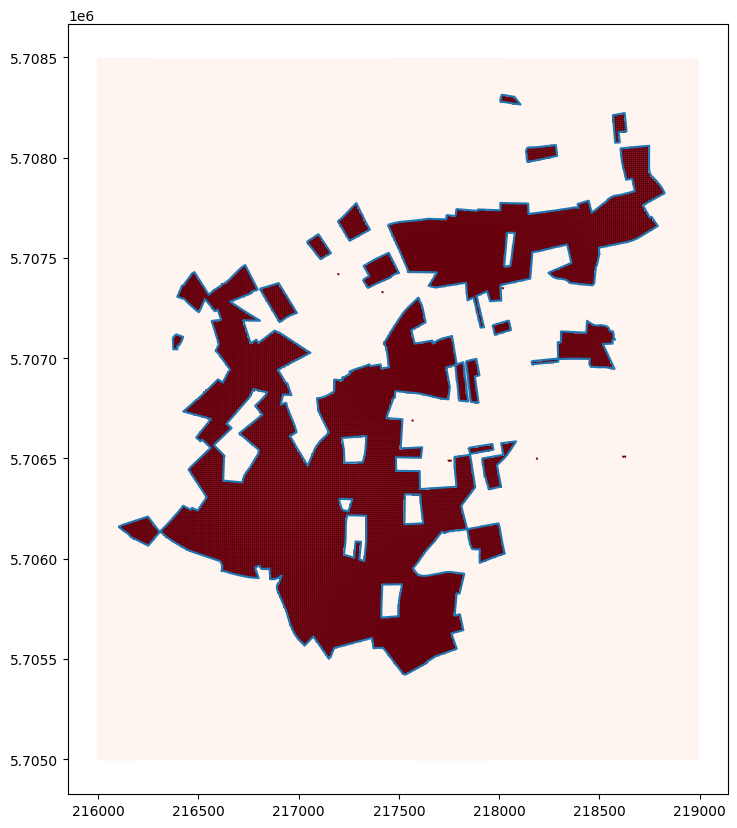

In [14]:
f, ax = plt.subplots(figsize=(10,10))

barrleNassau.boundary.plot(ax=ax)
ax.scatter(pnts_x, pnts_y, c=np.minimum(0.001, output.numpy()), cmap="Reds", s=1)